# Setup

## Pushing to my GitHub Repo

In [125]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

## 1. Load the Data

In [126]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [127]:
# Specify the directory where this notebook is located after %cd.
%cd "/content/drive/MyDrive/00_GCIGlobal/competition"


/content/drive/MyDrive/00_GCIGlobal/competition


In [128]:
train = pd.read_csv('input/train.csv', index_col='Id')
test  = pd.read_csv('input/test.csv',  index_col='Id')

print('Train shape:', train.shape)
print('Test shape: ', test.shape)
train.head()

Train shape: (2781, 15)
Test shape:  (696, 14)


,Year,Age,School,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Player_Type,Position_Type,Position,Drafted
Id,,,,,,,,,,,,,,,
0,2011,21.0,Lehigh,1.9050,140.160042,5.39,59.69,29.0,251.46,7.91,4.94,offense,offensive_lineman,OG,1.0
1,2011,24.0,Abilene Christian,1.8288,87.089735,4.31,101.60,16.0,332.74,NaN,NaN,offense,backs_receivers,WR,1.0
2,2018,21.0,Colorado St.,1.8542,92.986436,4.51,91.44,10.0,309.88,6.95,4.37,offense,backs_receivers,WR,1.0
3,2010,21.0,East Carolina,1.9304,148.778297,5.09,76.20,39.0,254.00,8.12,4.71,defense,defensive_lineman,DT,1.0
4,2016,21.0,California,1.8796,92.079251,4.64,78.74,NaN,281.94,7.13,4.20,offense,backs_receivers,WR,1.0


## 3. Data Analysis & EDA

### 3.1 Target Distribution

First, let's check how balanced the target is.

Draft rate: 0.648


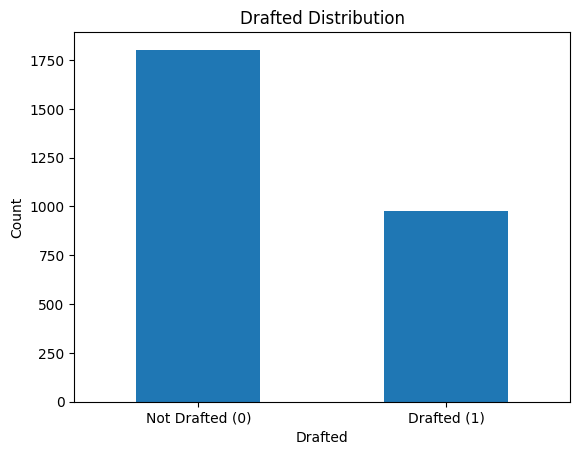

In [129]:
print('Draft rate:', train['Drafted'].mean().round(3))
train['Drafted'].value_counts().plot(kind='bar', title='Drafted Distribution')
plt.xticks([0, 1], ['Not Drafted (0)', 'Drafted (1)'], rotation=0)
plt.ylabel('Count')
plt.show()

### 3.2 Missing Values

Many physical test columns have missing values. Let's see how many.

In [130]:
missing = train.isnull().mean().sort_values(ascending=False)
print(missing[missing > 0])

Agility_3cone       0.348795
Shuttle             0.327940
Bench_Press_Reps    0.259259
Broad_Jump          0.208918
Vertical_Jump       0.199209
Age                 0.156419
Sprint_40yd         0.052140
dtype: float64


### 3.3 Draft Rate by Position Type

Some positions are drafted at much higher rates than others.

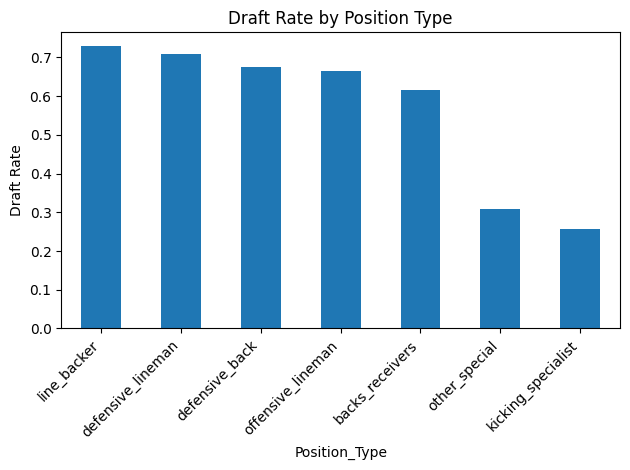

In [131]:
draft_by_pos = train.groupby('Position_Type')['Drafted'].mean().sort_values(ascending=False)
draft_by_pos.plot(kind='bar', title='Draft Rate by Position Type')
plt.ylabel('Draft Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 3.4 Physical Test vs Draft

Drafted players tend to run faster (lower 40-yard dash time).

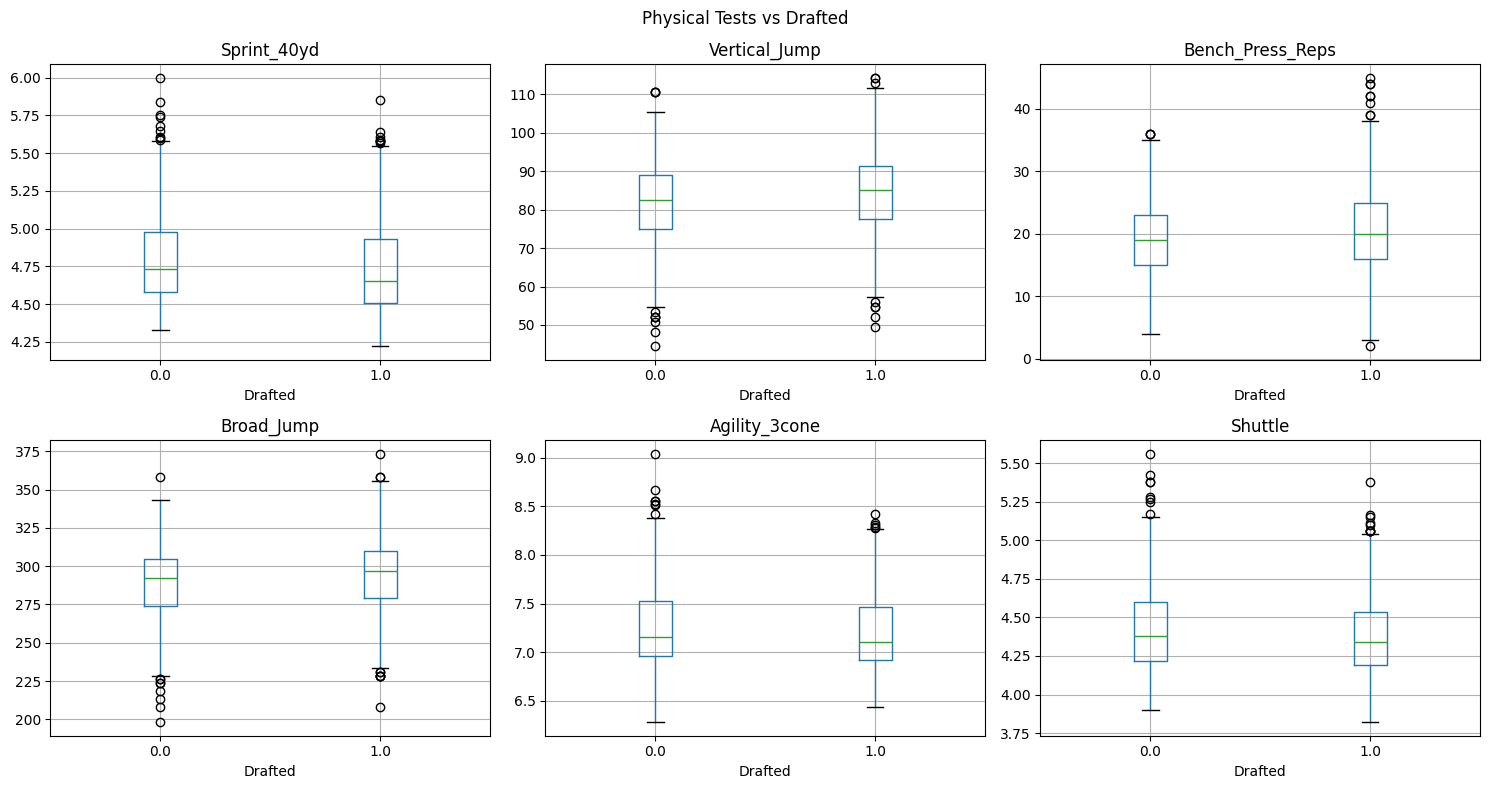

In [132]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
num_cols = ['Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps',
            'Broad_Jump', 'Agility_3cone', 'Shuttle']

for ax, col in zip(axes.flatten(), num_cols):
    train.boxplot(column=col, by='Drafted', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('Drafted')

plt.suptitle('Physical Tests vs Drafted')
plt.tight_layout()
plt.show()

### 3.5 School Draft Rate

The School column has 236 unique values, but it carries useful signal — players from top programs get drafted more often. Instead of dropping it (as the baseline does), we will use **target encoding** to capture this signal.

In [133]:
school_rate = (
    train.groupby('School')['Drafted']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'Draft_Rate', 'count': 'N'})
    .query('N >= 10')
    .sort_values('Draft_Rate', ascending=False)
)
print('Top 10 schools by draft rate:')
print(school_rate.head(10))
print('\nBottom 10 schools by draft rate:')
print(school_rate.tail(10))

Top 10 schools by draft rate:
                    Draft_Rate   N
School                            
Northwestern          0.846154  13
Louisiana Tech        0.800000  10
North Carolina St.    0.800000  25
Georgia Tech          0.800000  15
UCLA                  0.780488  41
Georgia               0.777778  54
Oklahoma              0.777778  54
Texas Tech            0.769231  13
Rutgers               0.750000  16
Oregon St.            0.750000  12

Bottom 10 schools by draft rate:
              Draft_Rate   N
School                      
Michigan St.    0.500000  38
Houston         0.500000  12
Kansas St.      0.473684  19
Syracuse        0.470588  17
San Jose St.    0.466667  15
Colorado St.    0.461538  13
Toledo          0.454545  11
Indiana         0.450000  20
Duke            0.384615  13
BYU             0.357143  14


## 4. Preprocessing

### 4.1 Separate Target

In [134]:
target = train['Drafted'].copy()
train  = train.drop(columns=['Drafted'])

print('Target shape:', target.shape)
print('Train shape: ', train.shape)

Target shape: (2781,)
Train shape:  (2781, 14)


### 4.2 Target Encoding for School

Instead of dropping School, we replace each school name with its historical draft rate.

**Why out-of-fold (OOF)?**  
If we compute the draft rate using the same rows we train on, the model will memorise the target — this is called **data leakage**. OOF encoding computes the rate on held-out folds only, so the encoding is honest.

In [135]:
school_te = np.zeros(len(train))
skf_te    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for tr_idx, val_idx in skf_te.split(train, target):
    # Compute draft rate per school using only the training fold
    school_mean = (
        train.iloc[tr_idx]
        .assign(Drafted=target.iloc[tr_idx])
        .groupby('School')['Drafted']
        .mean()
    )
    # Fill validation fold with the computed rate (unknown schools get global mean)
    school_te[val_idx] = (
        train.iloc[val_idx]['School']
        .map(school_mean)
        .fillna(target.mean())
    )

train['School_TE'] = school_te

# For test: use the full training set mean
school_mean_full = (
    train.assign(Drafted=target)
    .groupby('School')['Drafted']
    .mean()
)
test['School_TE'] = test['School'].map(school_mean_full).fillna(target.mean())

# Drop the raw School column
train = train.drop(columns=['School'])
test  = test.drop(columns=['School'])

print('School_TE sample:')
print(train['School_TE'].describe())

School_TE sample:
count    2781.000000
mean        0.653303
std         0.154609
min         0.000000
25%         0.600000
50%         0.666667
75%         0.739130
max         1.000000
Name: School_TE, dtype: float64


### 4.3 Label Encoding for Categorical Columns

We encode `Player_Type`, `Position_Type`, and `Position` as integers so the model can use them.

In [136]:
cat_cols = ['Player_Type', 'Position_Type', 'Position']
le = LabelEncoder()

for col in cat_cols:
    combined = pd.concat([train[col], test[col]], axis=0).astype(str)
    le.fit(combined)
    train[col] = le.transform(train[col].astype(str))
    test[col]  = le.transform(test[col].astype(str))

print('Categorical columns encoded.')
train[cat_cols].head()

Categorical columns encoded.


,Player_Type,Position_Type,Position
Id,,,
0,1,5,10
1,1,0,19
2,1,0,19
3,0,2,4
4,1,0,19


## 5. Feature Engineering

We create new features that capture athletic ability in ways the raw numbers do not.

| Feature | Formula | Why it helps |
|---|---|---|
| BMI | Weight / Height² | Body composition |
| Speed Score | Weight × 200 / Sprint_40yd⁴ | NFL standard: big fast players score higher |
| Burst Score | Vertical + Broad Jump | Explosive power |
| Agility Score | 3cone + Shuttle | Change-of-direction ability |
| Weight-Height Ratio | Weight / Height | Size relative to height |
| Year Recency | Year − 2009 | Scouting trends change over time |
| Age Missing Flag | 1 if Age is NaN | Missing age may itself be informative |

In [137]:
def add_features(df):
    df = df.copy()

    # BMI
    df['BMI'] = df['Weight'] / (df['Height'] ** 2)

    # Speed Score — standard NFL combine metric
    df['Speed_Score'] = (df['Weight'] * 200) / (df['Sprint_40yd'] ** 4)

    # Burst Score — explosive power
    df['Burst_Score'] = df['Vertical_Jump'] + df['Broad_Jump']

    # Agility Score — lower is better, so higher sum = worse agility
    df['Agility_Score'] = df['Agility_3cone'] + df['Shuttle']

    # Athletic Composite — combined jump and strength score
    df['Athletic_Composite'] = (
        df['Vertical_Jump'].fillna(df['Vertical_Jump'].median()) +
        df['Broad_Jump'].fillna(df['Broad_Jump'].median()) / 10 +
        df['Bench_Press_Reps'].fillna(df['Bench_Press_Reps'].median())
    )

    # Weight-to-height ratio
    df['Weight_Height_Ratio'] = df['Weight'] / df['Height']

    # Year recency
    df['Year_Recency'] = df['Year'] - 2009

    # Age missing flag
    df['Age_Missing'] = df['Age'].isna().astype(int)

    return df

train = add_features(train)
test  = add_features(test)

print('New features added. Train shape:', train.shape)
print('New columns:', ['BMI','Speed_Score','Burst_Score','Agility_Score',
                       'Athletic_Composite','Weight_Height_Ratio',
                       'Year_Recency','Age_Missing'])

New features added. Train shape: (2781, 22)
New columns: ['BMI', 'Speed_Score', 'Burst_Score', 'Agility_Score', 'Athletic_Composite', 'Weight_Height_Ratio', 'Year_Recency', 'Age_Missing']


### 5.1 Check New Features vs Draft


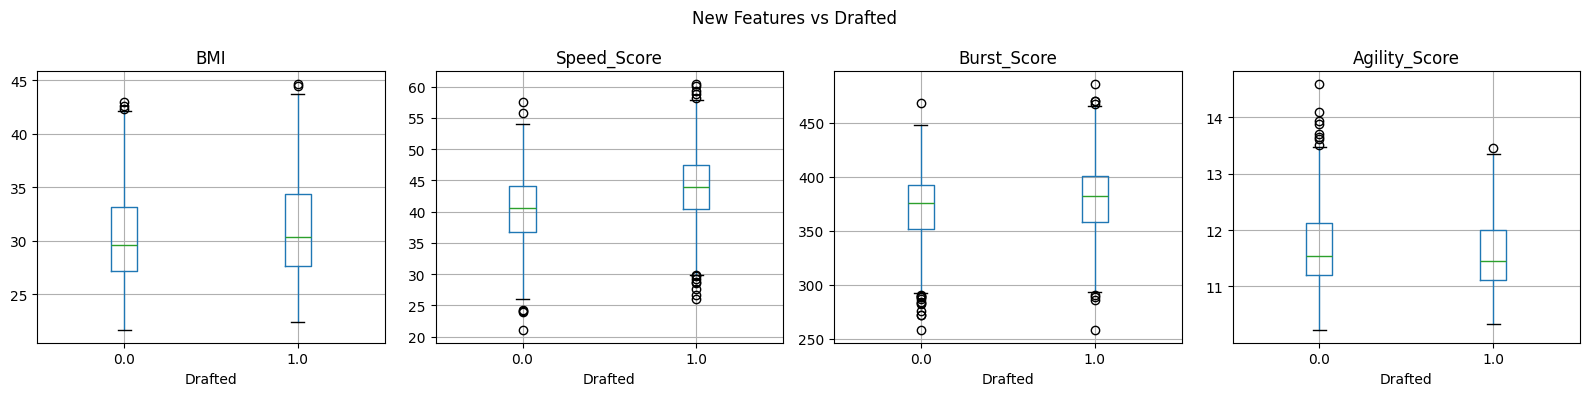

In [138]:
new_features = ['BMI', 'Speed_Score', 'Burst_Score', 'Agility_Score']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, new_features):
    train.assign(Drafted=target).boxplot(column=col, by='Drafted', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('Drafted')

plt.suptitle('New Features vs Drafted')
plt.tight_layout()
plt.show()

## 6. Model Training

### 6.1 Why LightGBM?

The baseline uses a Random Forest. We switch to **LightGBM** because:
- It handles missing values natively (no need to impute)
- It is faster and usually achieves higher AUC on tabular data
- It supports early stopping to avoid overfitting

### 6.2 Cross-Validation Strategy

We use **5-fold Stratified K-Fold** — the same as the baseline — to get a reliable estimate of AUC.

In [139]:
feature_cols = list(train.columns)
print(f'Total features: {len(feature_cols)}')
print(feature_cols)

Total features: 22
['Year', 'Age', 'Height', 'Weight', 'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps', 'Broad_Jump', 'Agility_3cone', 'Shuttle', 'Player_Type', 'Position_Type', 'Position', 'School_TE', 'BMI', 'Speed_Score', 'Burst_Score', 'Agility_Score', 'Athletic_Composite', 'Weight_Height_Ratio', 'Year_Recency', 'Age_Missing']


In [140]:
lgb_params = {
    'objective':         'binary',
    'metric':            'auc',
    'learning_rate':     0.05,
    'num_leaves':        63,
    'max_depth':         -1,
    'min_child_samples': 20,
    'feature_fraction':  0.8,
    'bagging_fraction':  0.8,
    'bagging_freq':      5,
    'reg_alpha':         0.1,
    'reg_lambda':        0.1,
    'verbose':           -1,
    'random_state':      42,
}

oof_preds  = np.zeros(len(train))
test_preds = np.zeros(len(test))
n_splits   = 5
skf        = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

for fold, (tr_idx, val_idx) in enumerate(skf.split(train, target)):
    X_tr,  y_tr  = train.iloc[tr_idx][feature_cols],  target.iloc[tr_idx]
    X_val, y_val = train.iloc[val_idx][feature_cols],  target.iloc[val_idx]

    dtrain = lgb.Dataset(X_tr,  label=y_tr)
    dval   = lgb.Dataset(X_val, label=y_val, reference=dtrain)

    model = lgb.train(
        lgb_params,
        dtrain,
        num_boost_round=1000,
        valid_sets=[dval],
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(200)
        ],
    )

    oof_preds[val_idx]  = model.predict(X_val[feature_cols])
    test_preds         += model.predict(test[feature_cols]) / n_splits

    fold_auc = roc_auc_score(y_val, oof_preds[val_idx])
    print(f'Fold {fold+1}  AUC: {fold_auc:.4f}  |  Best iteration: {model.best_iteration}')

overall_auc = roc_auc_score(target, oof_preds)
print(f'\nOverall OOF AUC: {overall_auc:.4f}')

Fold 1  AUC: 0.8278  |  Best iteration: 17
Fold 2  AUC: 0.8559  |  Best iteration: 21
Fold 3  AUC: 0.8488  |  Best iteration: 64
Fold 4  AUC: 0.8043  |  Best iteration: 30
Fold 5  AUC: 0.8475  |  Best iteration: 17

Overall OOF AUC: 0.8327


### 6.3 Feature Importance

Which features does the model rely on most?

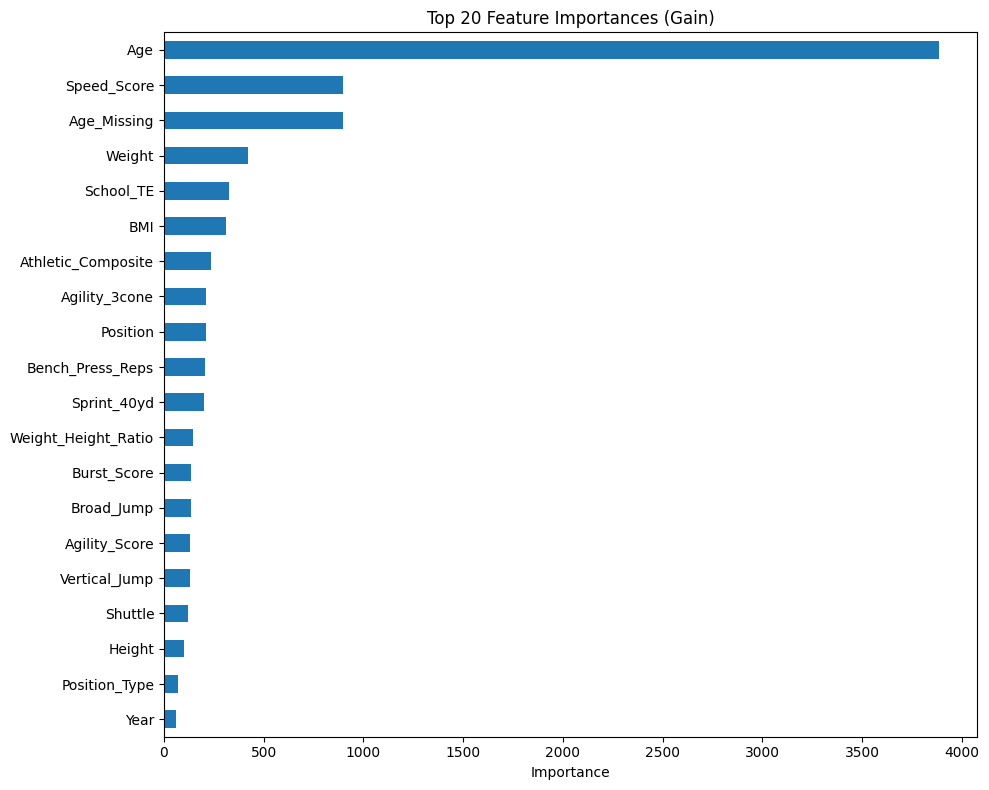

In [141]:
importance = pd.Series(
    model.feature_importance(importance_type='gain'),
    index=feature_cols
).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
importance.head(20).plot(kind='barh')
plt.title('Top 20 Feature Importances (Gain)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Create the Submission File

In [142]:
submission = pd.read_csv('input/sample_submission.csv')
submission['Drafted'] = test_preds
submission.to_csv('submission.csv', index=False)

print('submission.csv saved!')
print(submission.head())
print(f'\nPrediction range: {test_preds.min():.4f} — {test_preds.max():.4f}')

submission.csv saved!
     Id   Drafted
0  2781  0.653213
1  2782  0.779602
2  2783  0.815770
3  2784  0.798629
4  2785  0.774734

Prediction range: 0.1904 — 0.8848
